<a href="https://colab.research.google.com/github/zeets13/Flaggr_Project/blob/main/Notebook/Distilbert_Multi_Label.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Distilbert for Multi-Label Classification**

In [ ]:
import pandas as pd
import numpy as np

from datasets import load_dataset
dataset = load_dataset(
    "ucberkeley-dlab/measuring-hate-speech",
    "default"
)
df = dataset["train"].to_pandas()
print("Rows:", len(df))
print("Columns:", len(df.columns))


README.md:   0%|          | 0.00/11.4k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/135556 [00:00<?, ? examples/s]

Rows: 135556
Columns: 143


Extracting the columns we want to keep for training the model

Aggregating annotations based on the average score of each category

In [ ]:
category_columns = [
    "insult",
    "humiliate",
    "dehumanize",
    "violence",
    "genocide",
    "attack_defend"
]
agg_dict = {
    "text": "first",
    "hatespeech": list
}

for col in category_columns:
    agg_dict[col] = "mean"

df_grouped = (
    df.groupby("comment_id")
      .agg(agg_dict)
      .reset_index()
)
print("Shape:", df_grouped.shape)
print(df_grouped.columns.tolist())

for col in category_columns:

    df_grouped[col + "_label"] = (
        df_grouped[col] >= 0.5
    ).astype(int)


multi_label_columns = [
    "insult_label",
    "humiliate_label",
    "dehumanize_label",
    "violence_label",
    "genocide_label",
    "attack_defend_label"
]
for col in multi_label_columns:

    print("\n", col)
    print(df_grouped[col].value_counts())



Shape: (39565, 9)
['comment_id', 'text', 'hatespeech', 'insult', 'humiliate', 'dehumanize', 'violence', 'genocide', 'attack_defend']

 insult_label
insult_label
1    36330
0     3235
Name: count, dtype: int64

 humiliate_label
humiliate_label
1    35750
0     3815
Name: count, dtype: int64

 dehumanize_label
dehumanize_label
1    33910
0     5655
Name: count, dtype: int64

 violence_label
violence_label
1    21903
0    17662
Name: count, dtype: int64

 genocide_label
genocide_label
0    26131
1    13434
Name: count, dtype: int64

 attack_defend_label
attack_defend_label
1    38690
0      875
Name: count, dtype: int64


Using majority counts for grouping

In [ ]:
def majority_label(values):
    return pd.Series(values).mode()[0]
df_grouped["majority_hatespeech"] = (
    df_grouped["hatespeech"]
    .apply(majority_label)
)
print(
    df_grouped["majority_hatespeech"]
    .value_counts()
    .sort_index()
)

df_grouped["binary_label"] = (
    df_grouped["majority_hatespeech"] == 2
).astype(int)
print(
    df_grouped["binary_label"]
    .value_counts()
    .sort_index()
)

df_multi = df_grouped[
    [
        "comment_id",
        "text",
        "binary_label"
    ] + multi_label_columns
].copy()

print(df_multi.shape)
print(df_multi.columns.tolist())

majority_hatespeech
0.0    29304
1.0     1933
2.0     8328
Name: count, dtype: int64
binary_label
0    31237
1     8328
Name: count, dtype: int64
(39565, 9)
['comment_id', 'text', 'binary_label', 'insult_label', 'humiliate_label', 'dehumanize_label', 'violence_label', 'genocide_label', 'attack_defend_label']


Sampling 15k dataset using stratification strategy

In [ ]:

stratify_columns = [
    "binary_label",
    "insult_label",
    "humiliate_label",
    "dehumanize_label",
    "violence_label",
    "genocide_label",
    "attack_defend_label"
]

for col in stratify_columns:

    print(
        f"{col}: "
        f"{df_multi[col].mean():.4f}"
    )
!pip install iterative-stratification
from iterstrat.ml_stratifiers import (
    MultilabelStratifiedShuffleSplit
)

Y = df_multi[stratify_columns].values
X = df_multi.index.values.reshape(-1, 1)

target_size = 15000

remove_fraction = (
    1 - target_size / len(df_multi)
)

print("Remove fraction:", remove_fraction)
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=remove_fraction,
    random_state=42
)

selected_idx, _ = next(
    msss.split(X, Y)
)
df_15000 = df_multi.iloc[
    selected_idx
].copy()

df_15000 = df_15000.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)
print("Dataset size:", len(df_15000))

binary_label: 0.2105
insult_label: 0.9182
humiliate_label: 0.9036
dehumanize_label: 0.8571
violence_label: 0.5536
genocide_label: 0.3395
attack_defend_label: 0.9779
Remove fraction: 0.6208770377859218
Dataset size: 15000


Comparing with original dataset and splitting into (80/10/10) ratio

In [ ]:
print(" ORIGINAL DATASET")

for col in stratify_columns:

    print(
        f"{col}: "
        f"{df_multi[col].mean():.6f}"
    )


print("\nSample Dataset")

for col in stratify_columns:

    print(
        f"{col}: "
        f"{df_15000[col].mean():.6f}"
    )

Y_15000 = df_15000[
    stratify_columns
].values

X_15000 = df_15000.index.values.reshape(-1, 1)
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, temp_idx = next(
    msss.split(X_15000, Y_15000)
)
df_train = df_15000.iloc[
    train_idx
].copy()

df_temp = df_15000.iloc[
    temp_idx
].copy()
print("Train:", len(df_train))
print("Temporary:", len(df_temp))


Y_temp = df_temp[
    stratify_columns
].values

X_temp = df_temp.index.values.reshape(-1, 1)
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    msss.split(X_temp, Y_temp)
)
df_valid = df_temp.iloc[
    val_idx
].copy()

df_test = df_temp.iloc[
    test_idx
].copy()

print("Train:", len(df_train))
print("Validation:", len(df_valid))
print("Test:", len(df_test))

 ORIGINAL DATASET
binary_label: 0.210489
insult_label: 0.918236
humiliate_label: 0.903576
dehumanize_label: 0.857071
violence_label: 0.553595
genocide_label: 0.339543
attack_defend_label: 0.977884

Sample Dataset
binary_label: 0.210467
insult_label: 0.918267
humiliate_label: 0.903600
dehumanize_label: 0.857067
violence_label: 0.553600
genocide_label: 0.339533
attack_defend_label: 0.977867
Train: 12000
Temporary: 3000
Train: 12000
Validation: 1500
Test: 1500


Checking if the splitted dataset reserves the distribution of original dataset

In [ ]:
for name, dataset in [
    ("TRAIN", df_train),
    ("VALIDATION", df_valid),
    ("TEST", df_test)
]:

    print(name)

    for col in stratify_columns:

        print(
            f"{col}: "
            f"{dataset[col].mean():.4f}"
        )

TRAIN
binary_label: 0.2105
insult_label: 0.9183
humiliate_label: 0.9036
dehumanize_label: 0.8571
violence_label: 0.5536
genocide_label: 0.3395
attack_defend_label: 0.9778
VALIDATION
binary_label: 0.2100
insult_label: 0.9180
humiliate_label: 0.9033
dehumanize_label: 0.8573
violence_label: 0.5540
genocide_label: 0.3393
attack_defend_label: 0.9780
TEST
binary_label: 0.2107
insult_label: 0.9187
humiliate_label: 0.9040
dehumanize_label: 0.8567
violence_label: 0.5533
genocide_label: 0.3400
attack_defend_label: 0.9780


In [ ]:
from datasets import Dataset
model_columns = [
    "text"
] + multi_label_columns

train_dataset = Dataset.from_pandas(
    df_train[model_columns],
    preserve_index=False
)

valid_dataset = Dataset.from_pandas(
    df_valid[model_columns],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    df_test[model_columns],
    preserve_index=False
)

def create_labels(example):

    example["labels"] = [
        float(example[col])
        for col in multi_label_columns
    ]

    return example
train_dataset = train_dataset.map(
    create_labels
)

valid_dataset = valid_dataset.map(
    create_labels
)

test_dataset = test_dataset.map(
    create_labels
)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Preparing the tokenizer function

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=192
    )

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing each set

In [ ]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

valid_dataset = valid_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Remove unnecessary columns

In [ ]:
columns_to_remove = [
    "text"
] + multi_label_columns

train_dataset = train_dataset.remove_columns(
    columns_to_remove
)

valid_dataset = valid_dataset.remove_columns(
    columns_to_remove
)

test_dataset = test_dataset.remove_columns(
    columns_to_remove
)


In [ ]:
positive_weights = []

for col in multi_label_columns:

    positive = df_train[col].sum()

    negative = len(df_train) - positive

    weight = negative / positive

    positive_weights.append(weight)

    print(
        f"{col}: "
        f"positive={int(positive)}, "
        f"negative={int(negative)}, "
        f"pos_weight={weight:.4f}"
    )

import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

insult_label: positive=11019, negative=981, pos_weight=0.0890
humiliate_label: positive=10843, negative=1157, pos_weight=0.1067
dehumanize_label: positive=10285, negative=1715, pos_weight=0.1667
violence_label: positive=6643, negative=5357, pos_weight=0.8064
genocide_label: positive=4074, negative=7926, pos_weight=1.9455
attack_defend_label: positive=11734, negative=266, pos_weight=0.0227
cuda


Loading Distilbert-Base

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(multi_label_columns),
    problem_type="multi_label_classification"
)
model.to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)



Preparing the weighted trainer and fine tuning

In [ ]:
from transformers import Trainer

pos_weight_tensor = torch.tensor(
    positive_weights,
    dtype=torch.float
).to(device)

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_function = torch.nn.BCEWithLogitsLoss(
            pos_weight=pos_weight_tensor
        )

        loss = loss_function(
            logits,
            labels.float()
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

Defining evaluation metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    probabilities = 1 / (
        1 + np.exp(-logits)
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="micro",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="micro",
        zero_division=0
    )

    micro_f1 = f1_score(
        labels,
        predictions,
        average="micro",
        zero_division=0
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        labels,
        probabilities,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "roc_auc": roc_auc
    }

Creating training arguments

In [ ]:
from transformers import (
    TrainingArguments,
    EarlyStoppingCallback
)

training_args = TrainingArguments(
    output_dir="./results_multilabel",

    num_train_epochs=5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=1e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,

    report_to="none"
)

Model training

In [ ]:
processing_class=tokenizer

trainer = WeightedTrainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=valid_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Micro F1,Macro F1,Roc Auc
1,0.293829,0.277150,0.340667,0.891046,0.780073,0.831875,0.799694,0.811208
2,0.265086,0.277804,0.350000,0.889106,0.800000,0.842203,0.808468,0.812598
3,0.246787,0.282454,0.350000,0.893420,0.789744,0.838389,0.801850,0.811876
4,0.229501,0.290039,0.355333,0.900511,0.799707,0.847121,0.807850,0.811085


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.2588007609049479, metrics={'train_runtime': 905.7708, 'train_samples_per_second': 66.242, 'train_steps_per_second': 4.14, 'total_flos': 2384583266304000.0, 'train_loss': 0.2588007609049479, 'epoch': 4.0})

Evaluation on test set

In [ ]:
test_results = trainer.evaluate(
    test_dataset
)

print("===== TEST RESULTS =====")

for key, value in test_results.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,Micro F1,Macro F1,Roc Auc
0.229501,0.287876,4,0.354667,0.888944,0.780984,0.831475,0.799205,0.781552


===== TEST RESULTS =====
eval_loss: 0.2878756821155548
eval_accuracy: 0.3546666666666667
eval_precision: 0.888944472236118
eval_recall: 0.7809844711397598
eval_micro_f1: 0.8314746939093816
eval_macro_f1: 0.7992045927474131
eval_roc_auc: 0.7815519269974915


In [ ]:
pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
true_labels = pred_output.label_ids

probabilities = 1 / (
    1 + np.exp(-logits)
)

print("Logits shape:", logits.shape)
print("Labels shape:", true_labels.shape)
print("Probabilities shape:", probabilities.shape)

Logits shape: (1500, 6)
Labels shape: (1500, 6)
Probabilities shape: (1500, 6)


Classification report

In [ ]:
from sklearn.metrics import classification_report

for i, category in enumerate(multi_label_columns):

    predictions = (
        probabilities[:, i] >= 0.5
    ).astype(int)

    print("\n" + "=" * 50)
    print(category.upper())
    print("=" * 50)

    print(
        classification_report(
            true_labels[:, i],
            predictions,
            target_names=[
                "Negative",
                "Positive"
            ],
            zero_division=0
        )
    )


INSULT_LABEL
              precision    recall  f1-score   support

    Negative       0.29      0.76      0.42       122
    Positive       0.98      0.83      0.90      1378

    accuracy                           0.83      1500
   macro avg       0.63      0.80      0.66      1500
weighted avg       0.92      0.83      0.86      1500


HUMILIATE_LABEL
              precision    recall  f1-score   support

    Negative       0.31      0.76      0.44       144
    Positive       0.97      0.82      0.89      1356

    accuracy                           0.82      1500
   macro avg       0.64      0.79      0.67      1500
weighted avg       0.91      0.82      0.85      1500


DEHUMANIZE_LABEL
              precision    recall  f1-score   support

    Negative       0.37      0.65      0.47       215
    Positive       0.93      0.81      0.87      1285

    accuracy                           0.79      1500
   macro avg       0.65      0.73      0.67      1500
weighted avg       0.85  

In [ ]:
val_output = trainer.predict(
    valid_dataset
)

val_logits = val_output.predictions
val_labels = val_output.label_ids

val_probabilities = 1 / (
    1 + np.exp(-val_logits)
)

In [ ]:
test_results = trainer.evaluate(
    test_dataset
)

for key, value in test_results.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,Micro F1,Macro F1,Roc Auc
0.229501,0.287876,4,0.354667,0.888944,0.780984,0.831475,0.799205,0.781552


eval_loss: 0.2878756821155548
eval_accuracy: 0.3546666666666667
eval_precision: 0.888944472236118
eval_recall: 0.7809844711397598
eval_micro_f1: 0.8314746939093816
eval_macro_f1: 0.7992045927474131
eval_roc_auc: 0.7815519269974915


In [ ]:
five_categories = [
    "insult_label",
    "humiliate_label",
    "dehumanize_label",
    "violence_label",
    "genocide_label"
]
five_probabilities = probabilities[:, :5]
five_true_labels = true_labels[:, :5]

In [ ]:
from sklearn.metrics import classification_report

for i, category in enumerate(five_categories):

    predictions = (
        five_probabilities[:, i] >= 0.5
    ).astype(int)

    print("\n" + "=" * 60)
    print(category.upper())
    print("=" * 60)

    print(
        classification_report(
            five_true_labels[:, i],
            predictions,
            target_names=[
                "Negative",
                "Positive"
            ],
            zero_division=0
        )
    )


INSULT_LABEL
              precision    recall  f1-score   support

    Negative       0.29      0.76      0.42       122
    Positive       0.98      0.83      0.90      1378

    accuracy                           0.83      1500
   macro avg       0.63      0.80      0.66      1500
weighted avg       0.92      0.83      0.86      1500


HUMILIATE_LABEL
              precision    recall  f1-score   support

    Negative       0.31      0.76      0.44       144
    Positive       0.97      0.82      0.89      1356

    accuracy                           0.82      1500
   macro avg       0.64      0.79      0.67      1500
weighted avg       0.91      0.82      0.85      1500


DEHUMANIZE_LABEL
              precision    recall  f1-score   support

    Negative       0.37      0.65      0.47       215
    Positive       0.93      0.81      0.87      1285

    accuracy                           0.79      1500
   macro avg       0.65      0.73      0.67      1500
weighted avg       0.85  

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Your existing test probabilities/labels
five_probabilities = probabilities[:, :5]
five_true_labels = true_labels[:, :5]

# Current 0.5 threshold
five_predictions = (
    five_probabilities >= 0.5
).astype(int)

print("===== FIVE-CATEGORY RESULTS =====")

print(
    "Subset Accuracy:",
    accuracy_score(
        five_true_labels,
        five_predictions
    )
)

print(
    "Micro Precision:",
    precision_score(
        five_true_labels,
        five_predictions,
        average="micro",
        zero_division=0
    )
)

print(
    "Micro Recall:",
    recall_score(
        five_true_labels,
        five_predictions,
        average="micro",
        zero_division=0
    )
)

print(
    "Micro F1:",
    f1_score(
        five_true_labels,
        five_predictions,
        average="micro",
        zero_division=0
    )
)

print(
    "Macro F1:",
    f1_score(
        five_true_labels,
        five_predictions,
        average="macro",
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        five_true_labels,
        five_probabilities,
        average="macro"
    )
)

===== FIVE-CATEGORY RESULTS =====
Subset Accuracy: 0.4013333333333333
Micro Precision: 0.8656532456861133
Micro Recall: 0.7863407352117933
Micro F1: 0.8240930869267625
Macro F1: 0.7869345713893457
ROC-AUC: 0.7919244057228869


In [ ]:
val_output = trainer.predict(valid_dataset)

val_logits = val_output.predictions
val_labels = val_output.label_ids

val_probabilities = 1 / (
    1 + np.exp(-val_logits)
)

val_probabilities = val_probabilities[:, :5]
val_labels = val_labels[:, :5]

evaluating for different thresholds

In [ ]:
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

best_thresholds = {}

for i, category in enumerate(five_categories):

    best_threshold = 0.5
    best_macro_f1 = 0

    for threshold in thresholds:

        preds = (
            val_probabilities[:, i] >= threshold
        ).astype(int)

        score = f1_score(
            val_labels[:, i],
            preds,
            average="macro",
            zero_division=0
        )

        if score > best_macro_f1:

            best_macro_f1 = score
            best_threshold = threshold

    best_thresholds[category] = best_threshold

    print(
        f"{category}: "
        f"threshold={best_threshold:.2f}, "
        f"validation Macro-F1={best_macro_f1:.4f}"
    )

insult_label: threshold=0.10, validation Macro-F1=0.7539
humiliate_label: threshold=0.11, validation Macro-F1=0.7570
dehumanize_label: threshold=0.22, validation Macro-F1=0.7207
violence_label: threshold=0.47, validation Macro-F1=0.6840
genocide_label: threshold=0.58, validation Macro-F1=0.6568


In [ ]:
test_predictions = np.zeros_like(
    five_probabilities,
    dtype=int
)

for i, category in enumerate(five_categories):

    threshold = best_thresholds[category]

    test_predictions[:, i] = (
        five_probabilities[:, i] >= threshold
    ).astype(int)

In [ ]:
from sklearn.metrics import classification_report

for i, category in enumerate(five_categories):

    print("\n" + "=" * 60)
    print(category.upper())
    print("=" * 60)

    print(
        classification_report(
            true_labels[:, i],
            test_predictions[:, i],
            target_names=[
                "Negative",
                "Positive"
            ],
            zero_division=0
        )
    )


INSULT_LABEL
              precision    recall  f1-score   support

    Negative       0.48      0.42      0.45       122
    Positive       0.95      0.96      0.95      1378

    accuracy                           0.92      1500
   macro avg       0.72      0.69      0.70      1500
weighted avg       0.91      0.92      0.91      1500


HUMILIATE_LABEL
              precision    recall  f1-score   support

    Negative       0.48      0.47      0.47       144
    Positive       0.94      0.95      0.94      1356

    accuracy                           0.90      1500
   macro avg       0.71      0.71      0.71      1500
weighted avg       0.90      0.90      0.90      1500


DEHUMANIZE_LABEL
              precision    recall  f1-score   support

    Negative       0.48      0.50      0.49       215
    Positive       0.92      0.91      0.91      1285

    accuracy                           0.85      1500
   macro avg       0.70      0.71      0.70      1500
weighted avg       0.85  

In [ ]:
print("\n" + "=" * 60)
print("FINAL FIVE-CATEGORY TEST RESULTS")
print("=" * 60)

print(
    "Subset Accuracy:",
    accuracy_score(
        five_true_labels,
        test_predictions
    )
)

print(
    "Micro Precision:",
    precision_score(
        five_true_labels,
        test_predictions,
        average="micro",
        zero_division=0
    )
)

print(
    "Micro Recall:",
    recall_score(
        five_true_labels,
        test_predictions,
        average="micro",
        zero_division=0
    )
)

print(
    "Micro F1:",
    f1_score(
        five_true_labels,
        test_predictions,
        average="micro",
        zero_division=0
    )
)

print(
    "Macro F1:",
    f1_score(
        five_true_labels,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        five_true_labels,
        five_probabilities,
        average="macro"
    )
)


FINAL FIVE-CATEGORY TEST RESULTS
Subset Accuracy: 0.41
Micro Precision: 0.8669767441860465
Micro Recall: 0.8695652173913043
Micro F1: 0.8682690516117011
Macro F1: 0.8154237658335048
ROC-AUC: 0.7919244057228869


In [ ]:


for category, threshold in best_thresholds.items():
    print(
        f'"{category.replace("_label", "")}": '
        f'{threshold:.2f},'
    )

"insult": 0.10,
"humiliate": 0.11,
"dehumanize": 0.22,
"violence": 0.47,
"genocide": 0.58,


In [ ]:
test_predictions = np.zeros_like(
    five_probabilities,
    dtype=int
)

for i, category in enumerate(five_categories):

    threshold = best_thresholds[category]

    test_predictions[:, i] = (
        five_probabilities[:, i] >= threshold
    ).astype(int)

Saving the best model

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/model/distilbert_multilabel_final"

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("Model saved to:", MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/model/distilbert_multilabel_final


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Keeping the best thresholds for each category

In [ ]:
import json

CATEGORY_THRESHOLDS = {
    "insult": 0.10,
    "humiliate": 0.11,
    "dehumanize": 0.22,
    "violence": 0.47,
    "genocide": 0.58
}

with open(f"{MODEL_DIR}/thresholds.json", "w") as f:
    json.dump(CATEGORY_THRESHOLDS, f, indent=4)

print("Thresholds saved.")

Thresholds saved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

print(history.columns.tolist())

['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_micro_f1', 'eval_macro_f1', 'eval_roc_auc', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


Train vs val loss

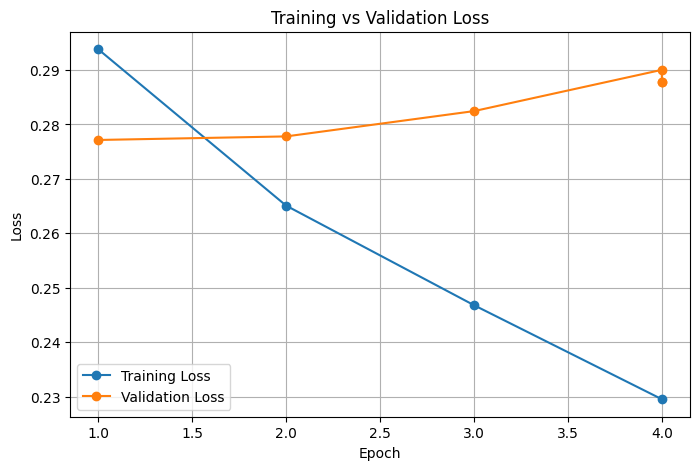

In [ ]:
train_history = history[
    history["loss"].notna()
]

eval_history = history[
    history["eval_loss"].notna()
]

plt.figure(figsize=(8,5))

plt.plot(
    train_history["epoch"],
    train_history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    eval_history["epoch"],
    eval_history["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

Macro F1-score

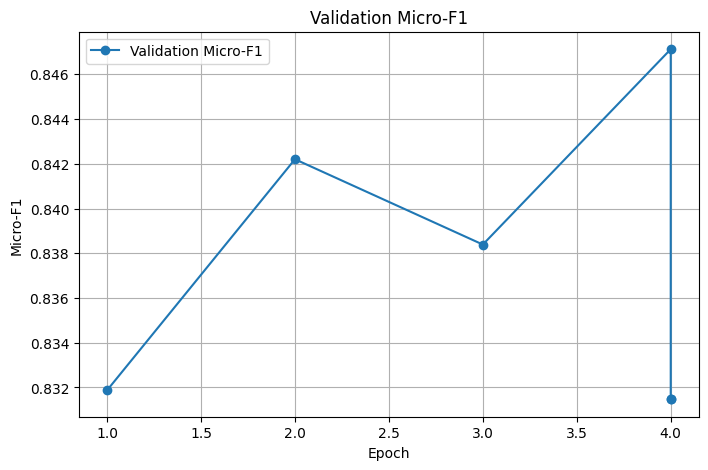

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_micro_f1"],
    marker="o",
    label="Validation Micro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Micro-F1")
plt.title("Validation Micro-F1")
plt.legend()
plt.grid()
plt.show()

Micro F1-score on validation set

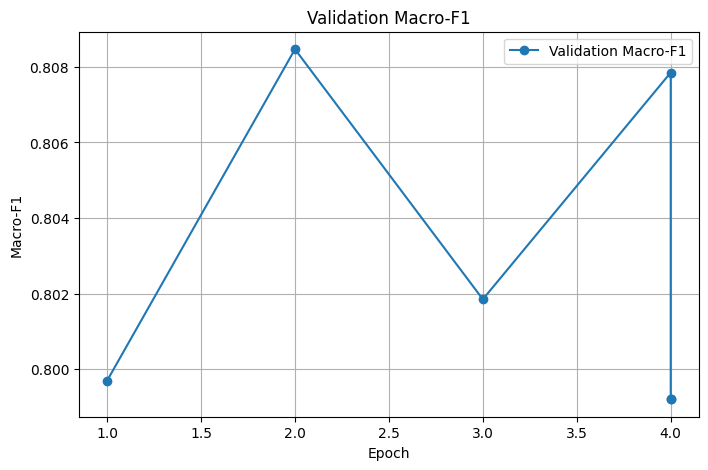

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_macro_f1"],
    marker="o",
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Validation Macro-F1")
plt.legend()
plt.grid()
plt.show()

Per category F1 score plotting

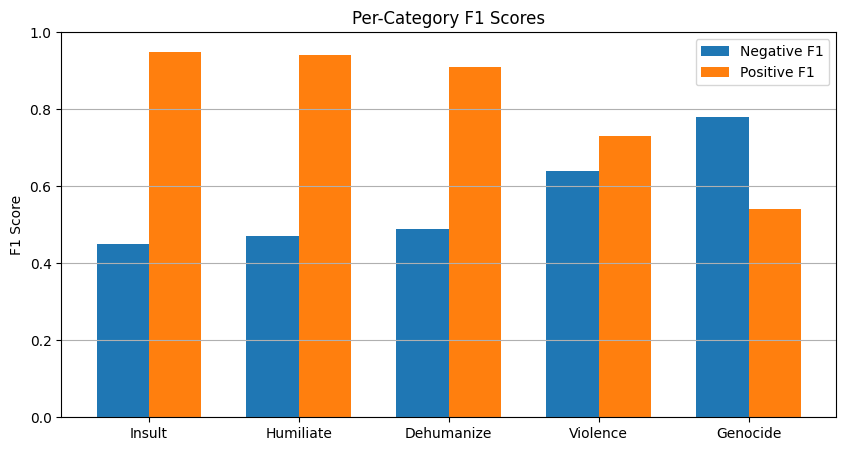

In [ ]:
categories = [
    "Insult",
    "Humiliate",
    "Dehumanize",
    "Violence",
    "Genocide"
]

negative_f1 = [0.45, 0.47, 0.49, 0.64, 0.78]
positive_f1 = [0.95, 0.94, 0.91, 0.73, 0.54]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    negative_f1,
    width,
    label="Negative F1"
)

plt.bar(
    x + width/2,
    positive_f1,
    width,
    label="Positive F1"
)

plt.xticks(x, categories)
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.title("Per-Category F1 Scores")
plt.legend()
plt.grid(axis="y")

plt.show()

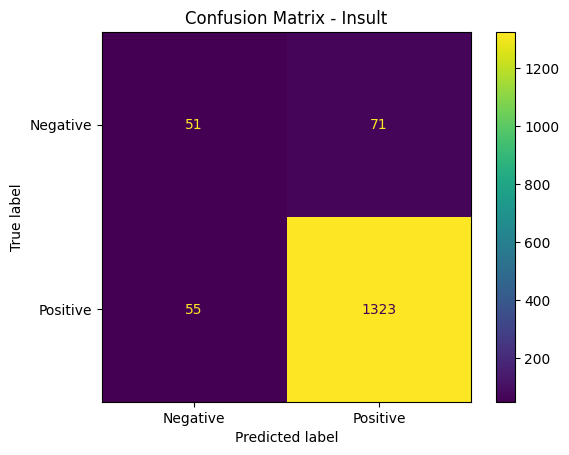

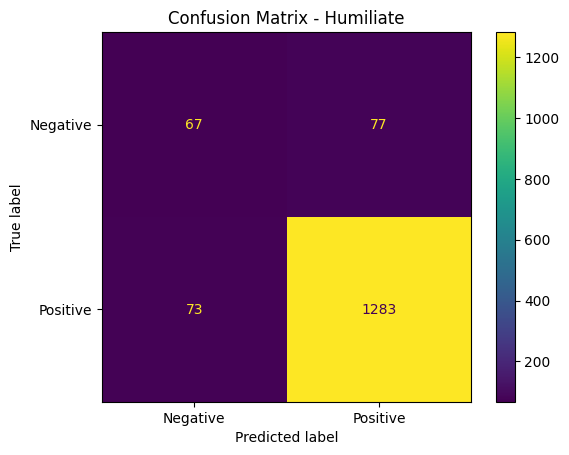

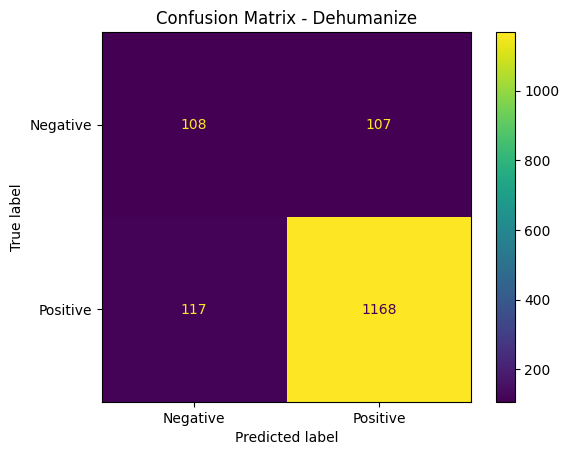

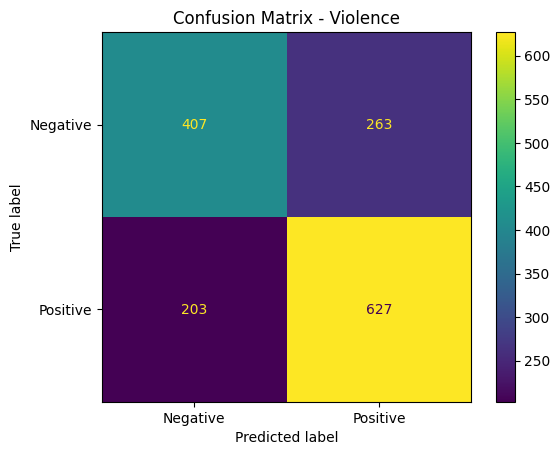

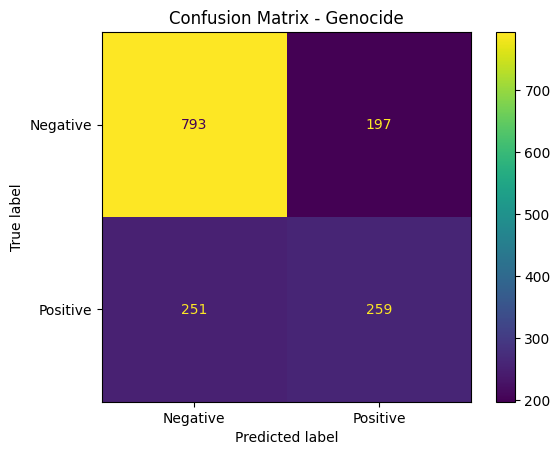

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for i, category in enumerate(five_categories):

    cm = confusion_matrix(
        five_true_labels[:, i],
        test_predictions[:, i]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot()

    plt.title(
        f"Confusion Matrix - {category.replace('_label','').title()}"
    )

    plt.show()